This notebook trains a binary classifier on a dataset which contains movie reviews which are labelled as containing either *positive* or *negative* sentiment towards the movie.

First we will install *sklearn* which we will be using to do the machine learning.

In [15]:
pip install scikit-learn

Next we will install the dataset. We will use the IMDB sentiment analysis dataset available from the [huggingface datasets library](https://huggingface.co/datasets/imdb) and described in [Maas et al. 2011](https://aclanthology.org/P11-1015.pdf).

In [2]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


Now let's load the IMDB training set. We will print out the last instance.

In [3]:
from datasets import load_dataset

imdb_dataset = load_dataset("imdb")['train']
print(imdb_dataset[-1])

{'text': 'The story centers around Barry McKenzie who must go to England if he wishes to claim his inheritance. Being about the grossest Aussie shearer ever to set foot outside this great Nation of ours there is something of a culture clash and much fun and games ensue. The songs of Barry McKenzie(Barry Crocker) are highlights.', 'label': 1}


Let's convert the training data into the format expected by scikit-learn - a list of input vectors (documents) and a list of associated output labels.

In [4]:
train_data = []
train_data_labels = []
for item in imdb_dataset:
  train_data.append(item['text'])
  train_data_labels.append(item['label'])
print(train_data[-1])
print(train_data_labels[-1])

The story centers around Barry McKenzie who must go to England if he wishes to claim his inheritance. Being about the grossest Aussie shearer ever to set foot outside this great Nation of ours there is something of a culture clash and much fun and games ensue. The songs of Barry McKenzie(Barry Crocker) are highlights.
1


We'll use the CountVectorizer class to extract the words in each review as the features the algorithm will learn from. Each document is represented as a 500 dimension vector of word counts. Only the 500 most frequent words are used in this version.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(analyzer='word',max_features=500,lowercase=True)
features = vectorizer.fit_transform(train_data).toarray()

As a sanity check, let's check we have a 2-d array where each row is one of the 25,000 instances and each column is one of 200 words. Print out the words that will be used for classification.

In [6]:
print(features.shape)
print(vectorizer.get_feature_names_out())

(25000, 500)
['10' 'able' 'about' 'absolutely' 'act' 'acting' 'action' 'actor' 'actors'
 'actress' 'actually' 'after' 'again' 'against' 'all' 'almost' 'along'
 'already' 'also' 'although' 'always' 'am' 'amazing' 'american' 'an' 'and'
 'another' 'any' 'anyone' 'anything' 'are' 'around' 'art' 'as' 'at'
 'audience' 'away' 'awful' 'back' 'bad' 'based' 'be' 'beautiful' 'because'
 'become' 'becomes' 'been' 'before' 'beginning' 'behind' 'being' 'believe'
 'best' 'better' 'between' 'big' 'bit' 'black' 'book' 'boring' 'both'
 'boy' 'br' 'budget' 'but' 'by' 'called' 'came' 'camera' 'can' 'car'
 'care' 'case' 'cast' 'certainly' 'character' 'characters' 'child'
 'children' 'cinema' 'classic' 'close' 'come' 'comedy' 'comes'
 'completely' 'could' 'couldn' 'couple' 'course' 'dark' 'day' 'days'
 'dead' 'death' 'definitely' 'despite' 'dialogue' 'did' 'didn' 'different'
 'direction' 'director' 'do' 'does' 'doesn' 'doing' 'don' 'done' 'down'
 'drama' 'during' 'dvd' 'each' 'early' 'effects' 'either' 'else

Split the data into a training and validation (dev) set. We'll use the validation set to test our model. We'll use 90% of the data for training and 10% for testing.

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(features,train_data_labels,train_size=0.9,random_state=123)

We will use Multinomial Naive Bayes to do the classification. Create the model.

In [8]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()

Train the model.

In [9]:
model = model.fit(X=X_train,y=y_train)

Test the model on the validation set.

In [10]:
y_pred = model.predict(X_val)

Now let's calculate the accuracy of the model's predictions on the validation set.

In [11]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_val,y_pred))

0.7744


## Confusion Matrix

[[963 296]
 [268 973]]


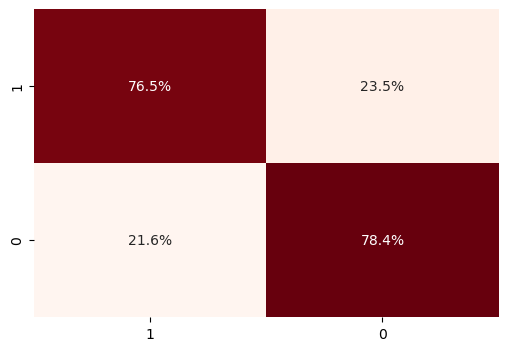

In [13]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labels = [1, 0]

cm = confusion_matrix(y_val, y_pred, labels=labels)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cmn * 100

# Create % signs on confusion matrix
annotations = np.asarray([['{:.1f}%'.format(value) for value in row] for row in cm_percent])

# Plot conusion matrix: with %
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_percent, annot=annotations, fmt='', cbar=False, cmap='Reds',
            xticklabels=labels, yticklabels=labels)

print(cm)

- True Positive: 77.5% of positive reviews were correctly predicted as positive = 963
- False Positive: 23.5% of positive review were incorrectly predicted as negative = 296
- True Negative: Just over 78% of negative reviews were correctly predicted as negative = 973
- False Negative: Almost 22% of negative review were incorrectly predicted as positive = 268

## Attempt to Increase Accuracy: Multinomial Naive Bayes

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer with similar parameters
vectorizer_new = TfidfVectorizer(analyzer="word", max_features=5000, lowercase=True)

# Fit and transform the training data
features_new = vectorizer_new.fit_transform(train_data).toarray()

x_train_new, x_val_new, y_train_new, y_val_new = train_test_split(features_new, train_data_labels,
                                                                  train_size=0.9, random_state=123)

model_new = MultinomialNB()
model_new = model_new.fit(X=x_train_new, y=y_train_new)

y_pred_new = model_new.predict(X=x_val_new)

# Compare accuracy of new model
print(f"Accuracy of Old Model: {accuracy_score(y_val, y_pred)*100}%")
print(f"Accuracy of New Model: {accuracy_score(y_val_new, y_pred_new)*100}%")

Accuracy of Old Model: 77.44%
Accuracy of New Model: 83.96000000000001%
